In [1]:
import nltk

print("Starting NLTK downloads...")
# Required for sentence and word tokenization
nltk.download('punkt')
# Database required for removing stopwords
nltk.download('stopwords')
# Database required for lemmatization 
nltk.download('wordnet')
print("NLTK downloads completed.")

Starting NLTK downloads...
NLTK downloads completed.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Berke\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Berke\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Berke\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('data/clickbait.csv') 

# Check data dimensions
print("Data Size:", df.shape) 

# Display the first 5 rows
print("\nFirst 5 Rows:")
print(df.head())

Data Size: (32000, 2)

First 5 Rows:
                                            headline  clickbait
0                                 Should I Get Bings          1
1      Which TV Female Friend Group Do You Belong In          1
2  The New "Star Wars: The Force Awakens" Trailer...          1
3  This Vine Of New York On "Celebrity Big Brothe...          1
4  A Couple Did A Stunning Photo Shoot With Their...          1


In [3]:
# Check label distribution (balance)
print("\nLabel Distribution:")
print(df['clickbait'].value_counts(normalize=True))

# Check for missing data
print("\nMissing Data Count:")
print(df.isna().sum())


Label Distribution:
clickbait
0    0.500031
1    0.499969
Name: proportion, dtype: float64

Missing Data Count:
headline     0
clickbait    0
dtype: int64


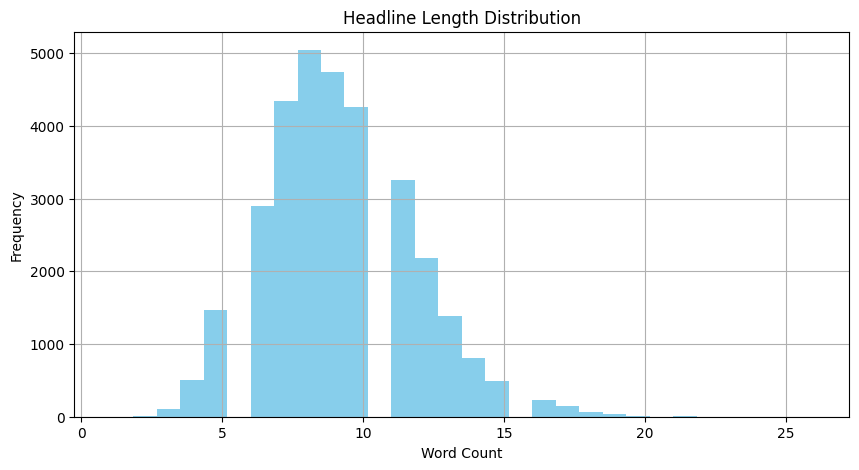

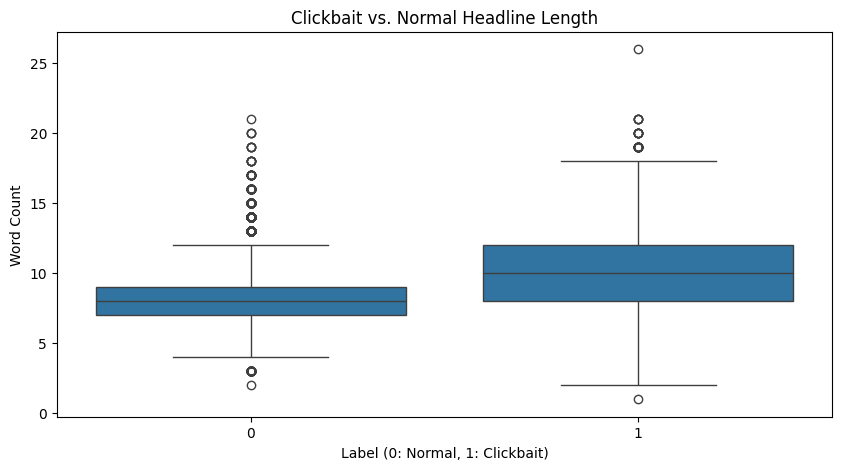

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate word count for each headline
df['length'] = df['headline'].apply(lambda x: len(x.split()))

# Display the distribution of all headline lengths using a histogram
plt.figure(figsize=(10, 5))
df['length'].hist(bins=30, color='skyblue')
plt.title('Headline Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

# Compare lengths of Clickbait vs. Normal headlines using a Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x='clickbait', y='length', data=df)
plt.title('Clickbait vs. Normal Headline Length')
plt.xlabel('Label (0: Normal, 1: Clickbait)')
plt.ylabel('Word Count')
plt.show()

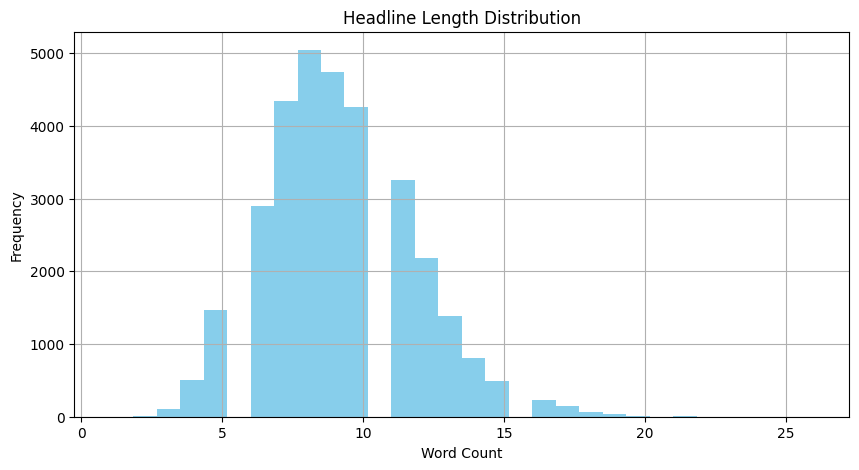

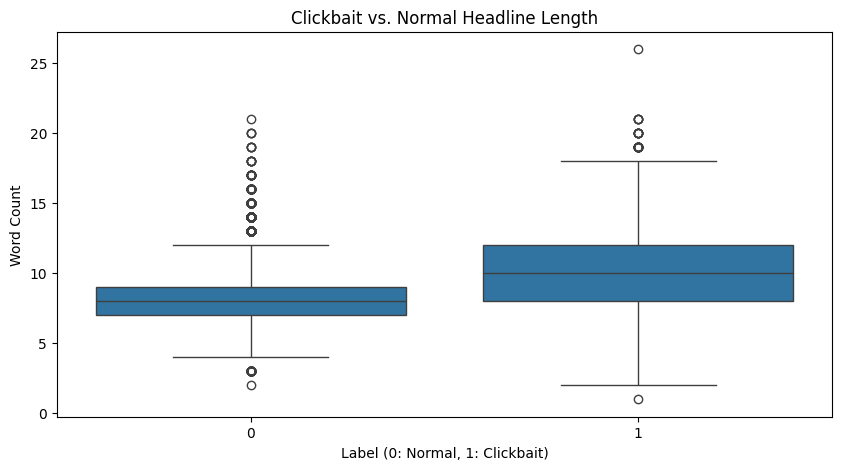

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate word count for each headline
df['length'] = df['headline'].apply(lambda x: len(x.split()))

# Display the distribution of all headline lengths using a histogram
plt.figure(figsize=(10, 5))
df['length'].hist(bins=30, color='skyblue')
plt.title('Headline Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

# Compare lengths of Clickbait vs. Normal headlines using a Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x='clickbait', y='length', data=df)
plt.title('Clickbait vs. Normal Headline Length')
plt.xlabel('Label (0: Normal, 1: Clickbait)')
plt.ylabel('Word Count')
plt.show()

In [6]:
from collections import Counter

# Combine all headlines, convert to lowercase, and split into words
words = ' '.join(df['headline']).lower().split()

# Count and display the top 20 most frequent words
print("\nTop 20 Most Frequent Words:")
print(Counter(words).most_common(20))


Top 20 Most Frequent Words:
[('to', 6656), ('in', 6466), ('the', 6149), ('of', 5100), ('you', 4828), ('a', 3961), ('for', 3163), ('and', 2814), ('on', 2759), ('your', 2578), ('is', 2128), ('are', 2110), ('that', 1904), ('this', 1851), ('with', 1609), ('at', 1542), ('will', 1382), ('from', 1357), ('new', 1226), ('about', 1158)]


In [7]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize Stopwords list and Lemmatizer
# Using a set for stopwords provides O(1) lookup speed
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Optimization: Compile Regex patterns once globally instead of inside the function.
# This makes the 'apply' operation significantly faster on large datasets.
PUNCT_REGEX = re.compile(f"[{re.escape(string.punctuation)}]")
DIGIT_REGEX = re.compile(r"\d+")

def clean_text(text):
    """Cleans the input text, removes stopwords, and applies lemmatization."""
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Replace punctuation with spaces
    text = PUNCT_REGEX.sub(" ", text)
    
    # 3. Remove numbers
    text = DIGIT_REGEX.sub(" ", text)
    
    # 4. & 5. Tokenization, Stopword removal, and Lemmatization
    tokens = [
        lemmatizer.lemmatize(w) for w in text.split() 
        if w not in STOP_WORDS and len(w) > 2 # Filter out words shorter than 2 characters
    ]
    
    return " ".join(tokens)

# Apply the cleaning function to the 'headline' column
print("Text cleaning and Lemmatization started...")
df['clean_text'] = df['headline'].apply(clean_text)
print("Text cleaning completed.")

# Compare cleaned vs. raw text
print("\nCleaned Text Example:")
print("Original:", df['headline'][10])
print("Cleaned :", df['clean_text'][10])

# We will use the 'clean_text' column from now on.

Text cleaning and Lemmatization started...
Text cleaning completed.

Cleaned Text Example:
Original: 16 Perfect Responses To The Indian Patriarchy
Cleaned : perfect response indian patriarchy


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Configure the Vectorizer:
# max_features=20000: Use the top 20,000 most frequent words/phrases.
# ngram_range=(1,2): Use unigrams (single words) and bigrams (two-word sequences).
# min_df=3: Include words that appear in at least 3 documents (headlines).
# max_df=0.9: Ignore words that appear in more than 90% of documents (too common/generic).
vec = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=3, max_df=0.9) 

print("TF-IDF transformation started...")
# Create X (feature matrix) using the 'clean_text' column
X = vec.fit_transform(df['clean_text']) 
# Create y (labels/targets) column
y = df['clickbait']

print(f"X matrix shape (Number of headlines, Number of features): {X.shape}")

TF-IDF transformation started...
X matrix shape (Number of headlines, Number of features): (32000, 13597)


In [9]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
# stratify=y: Maintains the same label distribution (balance) in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData successfully split:")
print(f"Training Set Size (X_train): {X_train.shape}")
print(f"Test Set Size (X_test): {X_test.shape}")

print("\nNow you are ready to train the model! 🎯")


Data successfully split:
Training Set Size (X_train): (25600, 13597)
Test Set Size (X_test): (6400, 13597)

Now you are ready to train the model! 🎯


In [10]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression model...")
# max_iter=500 is set high to ensure the model converges properly
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
print("Logistic Regression training completed.")

Training Logistic Regression model...
Logistic Regression training completed.


In [11]:
from sklearn.svm import LinearSVC

print("Training Support Vector Machine (SVM) model...")
# LinearSVC is generally faster and better suited for large text datasets compared to standard SVC
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
print("SVM training completed.")

Training Support Vector Machine (SVM) model...
SVM training completed.


--- Logistic Regression Performance Report ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3200
           1       0.96      0.94      0.95      3200

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400


--- SVM Performance Report ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3200
           1       0.96      0.95      0.95      3200

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



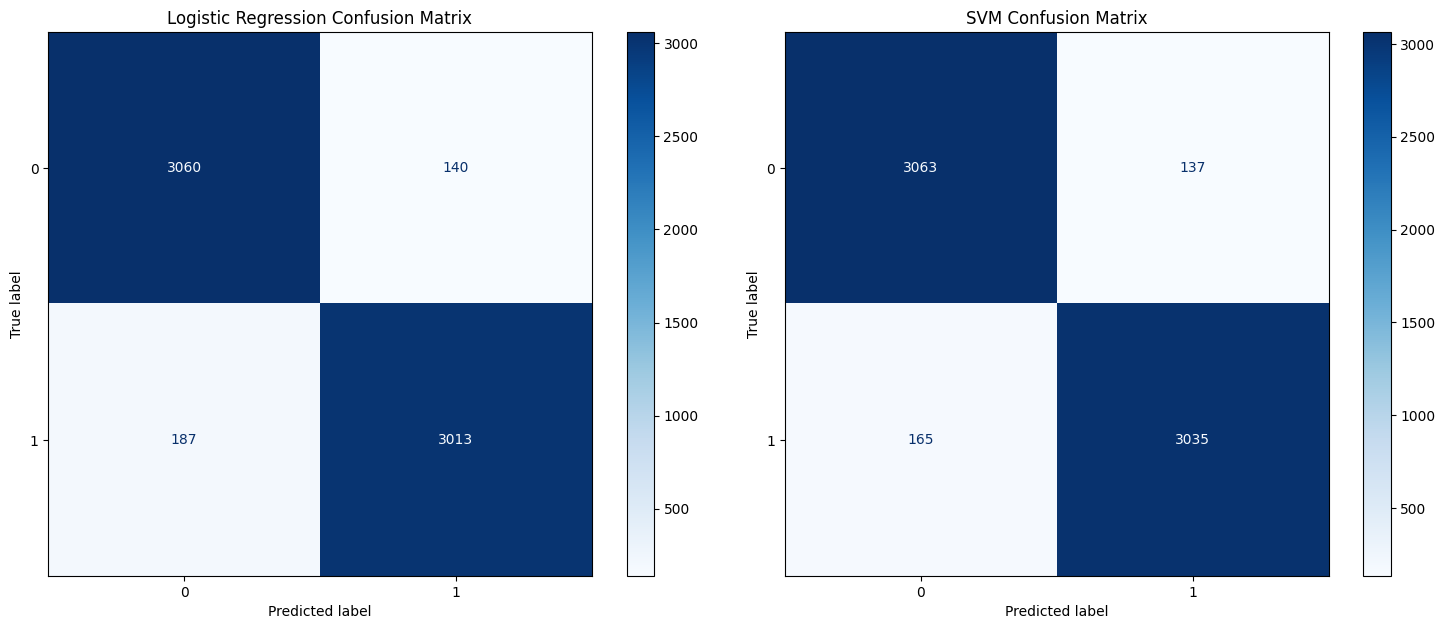

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Make Predictions (On Test Set)
y_pred_lr = lr.predict(X_test)
y_pred_svm = svm.predict(X_test)

# 2. Display Performance Reports
print("--- Logistic Regression Performance Report ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- SVM Performance Report ---")
print(classification_report(y_test, y_pred_svm))

# 3. Visualization (Confusion Matrix)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix for Logistic Regression
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, cmap=plt.cm.Blues, ax=ax[0])
ax[0].set_title("Logistic Regression Confusion Matrix")

# Confusion Matrix for SVM
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, cmap=plt.cm.Blues, ax=ax[1])
ax[1].set_title("SVM Confusion Matrix")

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd 

# Find indices where the actual labels (y_test) do not match the predictions (y_pred_svm)
wrong_indices = np.where(y_test != y_pred_svm)[0]

# Display the original headline and actual label for the first 10 misclassified examples
print("\n--- Top 10 Headlines Misclassified by SVM Model ---")

# We map the relative indices from the error list back to the original DataFrame's indices
# This is necessary because train_test_split shuffled the data
original_indices = y_test.index[wrong_indices[:10]]

# Print the specific columns to analyze why the model failed
print(df.loc[original_indices, ['headline', 'clickbait', 'clean_text']])


--- Top 10 Headlines Misclassified by SVM Model ---
                                                headline  clickbait  \
7169   Congrats, Denzel Washington! Actor To Receive ...          1   
4301                    Salted Coffee: Is It Less Bitter          1   
11712       Did "Project Runway" Choose The Right Winner          1   
21810   Nervous? Deodorant Makers Have a Product for You          0   
10641       How High-Maintenance Is Your Starbucks Order          1   
30123           The Incredible Shrinking Baseball Player          0   
20610  Aaron Boone, a Yankee Hero in 2003, Faces Hear...          0   
9899           24 Sounds That Will Take You Back To 2004          1   
12355  Tiger Cub Found Roaming The Streets In Souther...          1   
12995                         How Do You Ask For Consent          1   

                                              clean_text  
7169   congrats denzel washington actor receive cecil...  
4301                           salted coffee le

In [14]:
import joblib
import os

# Ensure the 'models/' directory exists
os.makedirs('models', exist_ok=True)

# Save the SVM model
joblib.dump(svm, 'models/svm_model.pkl')
print("SVM model successfully saved as 'models/svm_model.pkl'.")

# Save the TF-IDF vectorizer (Required: To use the same feature space when predicting new headlines)
joblib.dump(vec, 'models/tfidf_vectorizer.pkl')
print("TF-IDF Vectorizer successfully saved as 'models/tfidf_vectorizer.pkl'.")

SVM model successfully saved as 'models/svm_model.pkl'.
TF-IDF Vectorizer successfully saved as 'models/tfidf_vectorizer.pkl'.


In [15]:
import joblib
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os

# 1. Load saved tools
try:
    svm_model = joblib.load('models/svm_model.pkl')
    tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
    print("Model and Vectorizer loaded successfully.")
except FileNotFoundError:
    print("ERROR: Model or Vectorizer files not found in 'models/' directory.")
    # Exit script if models are missing
    exit()

# 2. Prepare text cleaning tools (Must match training phase exactly!)
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Optimization: Pre-compile Regex patterns globally
# This ensures consistency with the training and API code
PUNCT_REGEX = re.compile(f"[{re.escape(string.punctuation)}]")
DIGIT_REGEX = re.compile(r"\d+")

def clean_text(text):
    """Applies the cleaning steps used during training."""
    text = text.lower()
    
    # Use compiled regex for faster substitution
    text = PUNCT_REGEX.sub(" ", text)
    text = DIGIT_REGEX.sub(" ", text)
    
    tokens = [
        lemmatizer.lemmatize(w) for w in text.split() 
        if w not in STOP_WORDS and len(w) > 2
    ]
    return " ".join(tokens)

def predict_clickbait(headline):
    """
    Predicts whether the given headline is clickbait.
    """
    # a. Clean the headline
    clean_headline = clean_text(headline)
    
    # b. Convert headline to TF-IDF vector
    # Important: Use transform(), NOT fit_transform() (we used fit_transform in training)
    headline_vector = tfidf_vectorizer.transform([clean_headline])
    
    # c. Make prediction using the model
    prediction = svm_model.predict(headline_vector)[0]
    
    # d. Return result
    if prediction == 1:
        return "CLICKBAIT"
    else:
        return "NON-CLICKBAIT"

# Example tests:
test_headline_1 = "You Won't Believe What These 10 Celebrities Look Like Now!"
test_headline_2 = "France's President visits Berlin for economic talks."

print("-" * 30)
print(f"Headline 1: {test_headline_1}")
print(f"Prediction: {predict_clickbait(test_headline_1)}")

print("-" * 30)
print(f"Headline 2: {test_headline_2}")
print(f"Prediction: {predict_clickbait(test_headline_2)}")
print("-" * 30)

Model and Vectorizer loaded successfully.
------------------------------
Headline 1: You Won't Believe What These 10 Celebrities Look Like Now!
Prediction: CLICKBAIT
------------------------------
Headline 2: France's President visits Berlin for economic talks.
Prediction: NON-CLICKBAIT
------------------------------
